In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

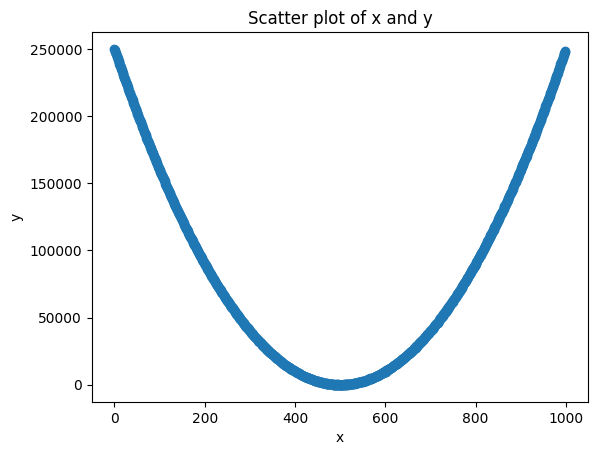

In [2]:
x = list(range(1000))
#y = [2*i + np.random.normal(0, i/4) for i in x]
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]

df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

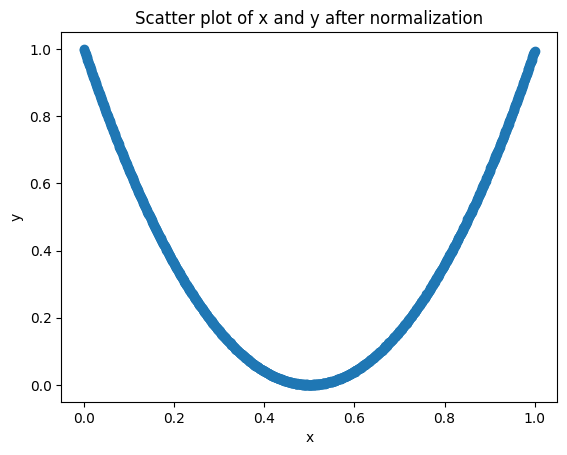

In [3]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [4]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [5]:
x_train

array([[0.        , 1.        ],
       [0.001001  , 0.99600854],
       [0.002002  , 0.99201984],
       ...,
       [0.997998  , 0.98934539],
       [0.998999  , 0.99115676],
       [1.        , 0.99385098]], shape=(1000, 2))

In [6]:
import keras

In [7]:
input_shape = (2,)
encoder = keras.models.Sequential([keras.layers.Dense(1)]) 
# if activaton is not defined, it is linear by default
decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        encoder, 
        decoder
])
autoencoder.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.01))
history = autoencoder.fit(x_train, x_train, epochs=20)
codings = encoder.predict(x_train)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2400  
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1445 
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1068 
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0878 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0773 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0708 
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0665 
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0634 
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0610 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0591 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0574 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0560 
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0547 
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0536 
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0526 
Epo

In [9]:
T = codings
T.shape
T

array([[-1.10760018e-01],
       [-1.09959275e-01],
       [-1.09158628e-01],
       [-1.08358532e-01],
       [-1.07558541e-01],
       [-1.06758647e-01],
       [-1.05959237e-01],
       [-1.05159916e-01],
       [-1.04361281e-01],
       [-1.03562608e-01],
       [-1.02764323e-01],
       [-1.01965994e-01],
       [-1.01168640e-01],
       [-1.00370482e-01],
       [-9.95732620e-02],
       [-9.87762064e-02],
       [-9.79800448e-02],
       [-9.71819684e-02],
       [-9.63861197e-02],
       [-9.55904871e-02],
       [-9.47948173e-02],
       [-9.40012038e-02],
       [-9.32043418e-02],
       [-9.24110189e-02],
       [-9.16145891e-02],
       [-9.08210278e-02],
       [-9.00266916e-02],
       [-8.92334133e-02],
       [-8.84391367e-02],
       [-8.76464546e-02],
       [-8.68523270e-02],
       [-8.60599652e-02],
       [-8.52706432e-02],
       [-8.44764039e-02],
       [-8.36836398e-02],
       [-8.28922987e-02],
       [-8.21037441e-02],
       [-8.13094974e-02],
       [-8.0

In [10]:
newdf = decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0.07424539, 0.5001038 ],
       [0.07520238, 0.49973965],
       [0.07615924, 0.4993756 ],
       ...,
       [0.8679512 , 0.1981374 ],
       [0.8686737 , 0.19786254],
       [0.8693604 , 0.19760129]], shape=(1000, 2), dtype=float32)

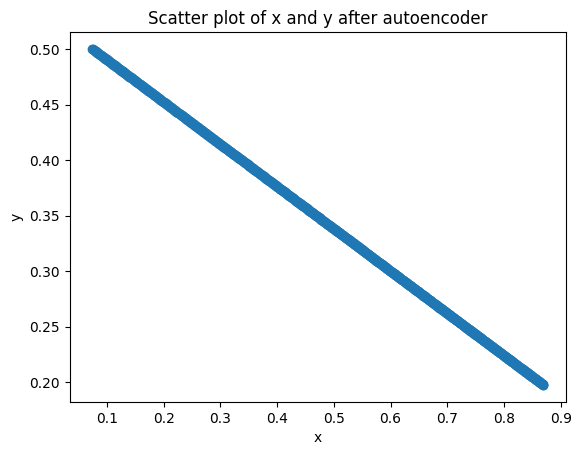

In [11]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()